# 🏦 Customer Engagement & Product Utilization Analytics for Retention Strategy
### The European Central Bank  |  Dataset: 10,000 Customers  |  Year: 2025

---

**Project Sections:**
1. Setup & Imports
2. Data Loading & Validation
3. Feature Engineering
4. Engagement Analysis
5. Product Utilization Analysis
6. Financial Commitment Analysis
7. Retention Strength & Risk Segments
8. Full Analytics Dashboard
9. Key Insights & Recommendations


## 1. 📦 Setup & Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#F8F9FB',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.color':        '#EAEEF4',
    'grid.linewidth':    0.7,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlecolor':   '#1F3B73',
    'axes.labelsize':    10,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
})

NAVY   = '#1F3B73'
BLUE   = '#2E6FD8'
TEAL   = '#0E9B8A'
ORANGE = '#E8580A'
RED    = '#C0392B'
GREEN  = '#1A9641'
GOLD   = '#C59B0A'
LGRAY  = '#F0F2F8'

print('Libraries imported successfully.')
print(f'  pandas {pd.__version__}  |  numpy {np.__version__}  |  matplotlib {plt.matplotlib.__version__}')


Libraries imported successfully.
  pandas 2.3.3  |  numpy 2.3.5  |  matplotlib 3.10.6


## 2. 🔍 Data Loading & Validation

In [2]:
df = pd.read_csv('European_Bank.csv')
print(f'Dataset loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()


Dataset loaded: 10,000 rows x 14 columns


,Year,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,2025,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2025,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,2025,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,2025,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,2025,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [3]:
print('=' * 52)
print('  DATA QUALITY REPORT')
print('=' * 52)
print(f'  Total Records : {len(df):,}')
print(f'  Total Columns : {df.shape[1]}')
print(f'  Null Values   : {df.isnull().sum().sum()}')
print(f'  Duplicates    : {df.duplicated().sum()}')
print('=' * 52)
quality = df.dtypes.to_frame('dtype').join(df.isnull().sum().to_frame('nulls')).join(df.nunique().to_frame('unique'))
print(quality)


  DATA QUALITY REPORT
  Total Records : 10,000
  Total Columns : 14
  Null Values   : 0
  Duplicates    : 0
                   dtype  nulls  unique
Year               int64      0       1
CustomerId         int64      0   10000
Surname           object      0    2932
CreditScore        int64      0     460
Geography         object      0       3
Gender            object      0       2
Age                int64      0      70
Tenure             int64      0      11
Balance          float64      0    6382
NumOfProducts      int64      0       4
HasCrCard          int64      0       2
IsActiveMember     int64      0       2
EstimatedSalary  float64      0    9999
Exited             int64      0       2


In [4]:
numeric_cols = ['CreditScore','Age','Tenure','Balance','NumOfProducts',
                'HasCrCard','IsActiveMember','EstimatedSalary','Exited']
df[numeric_cols].describe().round(2)


,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.00,10000.0
mean,650.53,38.92,5.01,76485.89,1.53,0.71,0.52,100090.24,0.2
std,96.65,10.49,2.89,62397.41,0.58,0.46,0.50,57510.49,0.4
min,350.00,18.00,0.00,0.00,1.00,0.00,0.00,11.58,0.0
25%,584.00,32.00,3.00,0.00,1.00,0.00,0.00,51002.11,0.0
50%,652.00,37.00,5.00,97198.54,1.00,1.00,1.00,100193.92,0.0
75%,718.00,44.00,7.00,127644.24,2.00,1.00,1.00,149388.25,0.0
max,850.00,92.00,10.00,250898.09,4.00,1.00,1.00,199992.48,1.0


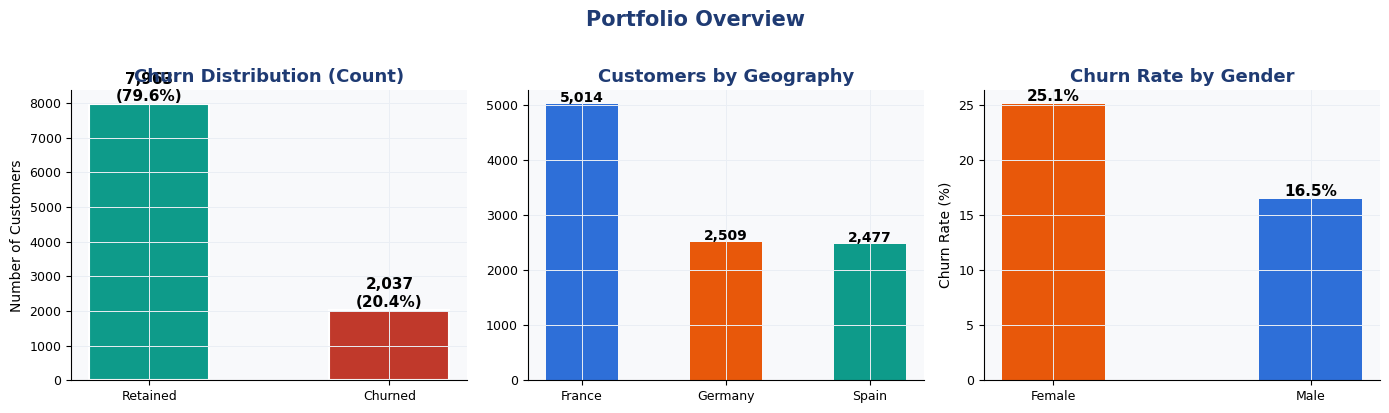

Overall Churn Rate: 20.37%


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

counts = df['Exited'].value_counts()
axes[0].bar(['Retained', 'Churned'], counts.values, color=[TEAL, RED], width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(axes[0].patches, counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 80,
                 f'{val:,}\n({val/len(df)*100:.1f}%)', ha='center', fontsize=11, fontweight='bold')
axes[0].set_title('Churn Distribution (Count)')
axes[0].set_ylabel('Number of Customers')

geo_counts = df['Geography'].value_counts()
axes[1].bar(geo_counts.index, geo_counts.values, color=[BLUE, ORANGE, TEAL], width=0.5)
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{bar.get_height():,.0f}', ha='center', fontsize=10, fontweight='bold')
axes[1].set_title('Customers by Geography')

gen_churn = df.groupby('Gender')['Exited'].mean() * 100
axes[2].bar(gen_churn.index, gen_churn.values, color=[ORANGE, BLUE], width=0.4)
for bar in axes[2].patches:
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f'{bar.get_height():.1f}%', ha='center', fontsize=11, fontweight='bold')
axes[2].set_title('Churn Rate by Gender')
axes[2].set_ylabel('Churn Rate (%)')

plt.suptitle('Portfolio Overview', fontsize=15, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig('fig_01_overview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Overall Churn Rate: {df["Exited"].mean()*100:.2f}%')


## 3. Engineering Features

Derived features created:
- **EngagementScore** (0-9): composite behavioral score = `(IsActiveMember x 3) + min(NumOfProducts,3) + HasCrCard + min(Tenure/2,2)`
- **EngagementTier**: Low (0-3) / Medium (4-6) / High (7-9)
- **RetentionStrength**: `EngagementScore x 0.4 + ProductIndex x 0.6`
- **RetentionTier**: At Risk / Moderate / Stable / Loyal
- **HighValueDisengaged (HVD)**: Balance > Q75 AND IsActiveMember = 0
- **SilentPremiumChurn (SPC)**: Salary > Q75 AND Products <= 1 AND Exited = 1


In [6]:
def compute_engagement(row):
    return (row['IsActiveMember'] * 3
            + min(row['NumOfProducts'], 3)
            + row['HasCrCard']
            + min(row['Tenure'] / 2, 2))

df['EngagementScore'] = df.apply(compute_engagement, axis=1)
df['EngagementTier']  = df['EngagementScore'].apply(
    lambda s: 'High' if s >= 7 else ('Medium' if s >= 4 else 'Low')
)
df['ProductIndex']      = df['NumOfProducts'] + df['HasCrCard'] * 0.5
df['RetentionStrength'] = df['EngagementScore'] * 0.4 + df['ProductIndex'] * 0.6
df['RetentionTier']     = pd.cut(df['RetentionStrength'],
                                  bins=[0, 3, 5, 7, 99],
                                  labels=['At Risk', 'Moderate', 'Stable', 'Loyal'])
df['BalanceBand'] = pd.cut(df['Balance'],
                            bins=[-1, 1, 50000, 100000, 150000, 999999],
                            labels=['Zero', '1-50K', '50-100K', '100-150K', '150K+'])
df['AgeGroup'] = pd.cut(df['Age'],
                         bins=[17, 25, 35, 45, 55, 65, 100],
                         labels=['18-25', '26-35', '36-45', '46-55', '56-65', '65+'])

bal_q75 = df['Balance'].quantile(0.75)
sal_q75 = df['EstimatedSalary'].quantile(0.75)

df['HighValueDisengaged'] = ((df['Balance'] > bal_q75) & (df['IsActiveMember'] == 0)).astype(int)
df['SilentPremiumChurn']  = ((df['EstimatedSalary'] > sal_q75) &
                              (df['NumOfProducts'] <= 1) &
                              (df['Exited'] == 1)).astype(int)

print('Feature engineering complete.')
print(f'  Balance Q75 threshold : EU{bal_q75:,.0f}')
print(f'  Salary  Q75 threshold : EU{sal_q75:,.0f}')
print(f'  HVD Customers         : {df["HighValueDisengaged"].sum():,}')
print(f'  SPC Customers         : {df["SilentPremiumChurn"].sum():,}')


Feature engineering complete.
  Balance Q75 threshold : EU127,644
  Salary  Q75 threshold : EU149,388
  HVD Customers         : 1,247
  SPC Customers         : 371


In [7]:
df[['CustomerId','Geography','Age','Balance','EngagementScore','EngagementTier',
    'RetentionTier','HighValueDisengaged','SilentPremiumChurn','Exited']].head(10)


,CustomerId,Geography,Age,Balance,EngagementScore,EngagementTier,RetentionTier,HighValueDisengaged,SilentPremiumChurn,Exited
0,15634602,France,42,0.00,6.0,Medium,Moderate,0,0,1
1,15647311,Spain,41,83807.86,4.5,Medium,At Risk,0,0,0
2,15619304,France,42,159660.80,6.0,Medium,Moderate,1,0,1
3,15701354,France,39,0.00,2.5,Low,At Risk,0,0,0
4,15737888,Spain,43,125510.82,6.0,Medium,Moderate,0,0,0
5,15574012,Spain,44,113755.78,5.0,Medium,Moderate,0,0,1
6,15592531,France,50,0.00,8.0,High,Moderate,0,0,0
7,15656148,Germany,29,115046.74,6.0,Medium,Stable,0,0,1
8,15792365,France,44,142051.07,7.0,High,Moderate,0,0,0
9,15592389,France,27,134603.88,6.0,Medium,Moderate,0,0,0


## 4. Engagement Analysis

In [8]:
eng_summary = df.groupby('EngagementTier').agg(
    Count        = ('Exited', 'count'),
    Churn_Rate   = ('Exited', 'mean'),
    Avg_Balance  = ('Balance', 'mean'),
    Avg_Products = ('NumOfProducts', 'mean'),
    Active_Pct   = ('IsActiveMember', 'mean'),
    Avg_Age      = ('Age', 'mean')
).reindex(['Low', 'Medium', 'High'])
eng_summary['Churn_Rate']  = (eng_summary['Churn_Rate'] * 100).round(1)
eng_summary['Active_Pct']  = (eng_summary['Active_Pct'] * 100).round(1)
eng_summary['Avg_Balance'] = eng_summary['Avg_Balance'].round(0)
eng_summary['Avg_Products']= eng_summary['Avg_Products'].round(2)
eng_summary['Avg_Age']     = eng_summary['Avg_Age'].round(1)
print('ENGAGEMENT TIER SUMMARY')
print('=' * 65)
print(eng_summary.to_string())


ENGAGEMENT TIER SUMMARY
                Count  Churn_Rate  Avg_Balance  Avg_Products  Active_Pct  Avg_Age
EngagementTier                                                                   
Low              1722        31.0      88732.0          1.23         0.0     38.6
Medium           5058        21.9      77465.0          1.52        38.2     38.6
High             3220        12.3      68398.0          1.70       100.0     39.5


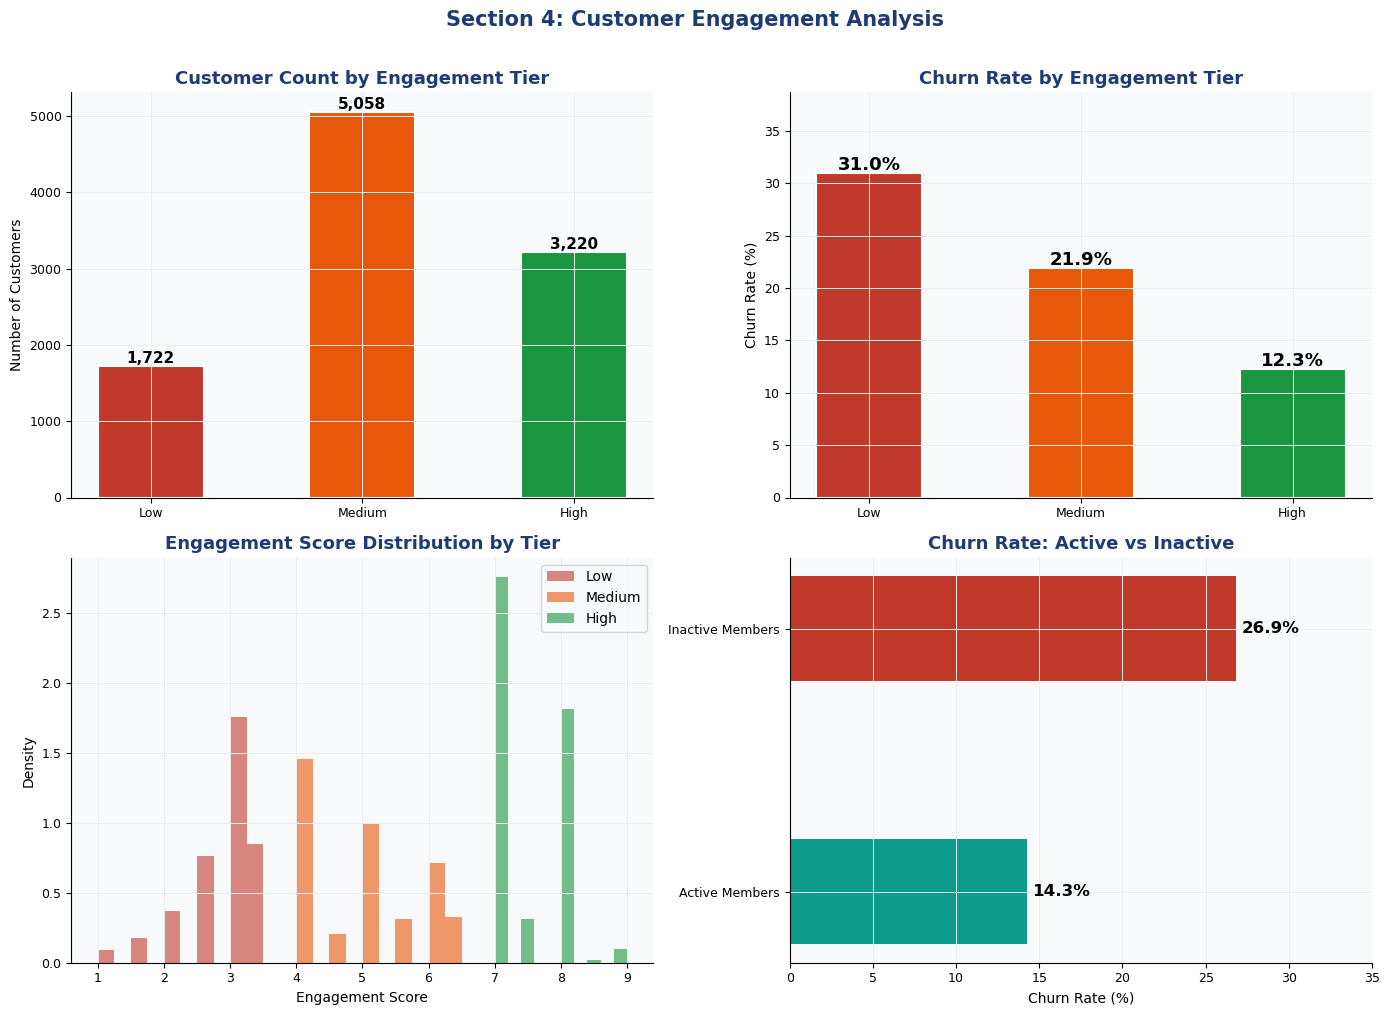

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

tiers = ['Low', 'Medium', 'High']
tier_colors = [RED, ORANGE, GREEN]
tier_counts = df['EngagementTier'].value_counts().reindex(tiers)
tier_churn  = df.groupby('EngagementTier')['Exited'].mean().reindex(tiers) * 100

# 4.1 Tier Distribution
axes[0,0].bar(tiers, tier_counts.values, color=tier_colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(axes[0,0].patches, tier_counts.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                   f'{val:,}', ha='center', fontweight='bold', fontsize=11)
axes[0,0].set_title('Customer Count by Engagement Tier')
axes[0,0].set_ylabel('Number of Customers')

# 4.2 Churn by Tier
bars = axes[0,1].bar(tiers, tier_churn.values, color=tier_colors, width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, tier_churn.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{val:.1f}%', ha='center', fontweight='bold', fontsize=13)
axes[0,1].set_title('Churn Rate by Engagement Tier')
axes[0,1].set_ylabel('Churn Rate (%)')
axes[0,1].set_ylim(0, max(tier_churn.values) * 1.25)

# 4.3 Score Distribution
for label, color in zip(['Low','Medium','High'], tier_colors):
    sub = df[df['EngagementTier'] == label]
    axes[1,0].hist(sub['EngagementScore'], bins=10, alpha=0.6,
                   color=color, label=label, density=True)
axes[1,0].set_title('Engagement Score Distribution by Tier')
axes[1,0].set_xlabel('Engagement Score')
axes[1,0].set_ylabel('Density')
axes[1,0].legend()

# 4.4 Active vs Inactive
active_churn   = df[df['IsActiveMember']==1]['Exited'].mean() * 100
inactive_churn = df[df['IsActiveMember']==0]['Exited'].mean() * 100
bars2 = axes[1,1].barh(['Active Members','Inactive Members'],
                        [active_churn, inactive_churn], color=[TEAL, RED], height=0.4)
for bar, val in zip(bars2, [active_churn, inactive_churn]):
    axes[1,1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                   f'{val:.1f}%', va='center', fontweight='bold', fontsize=12)
axes[1,1].set_title('Churn Rate: Active vs Inactive')
axes[1,1].set_xlabel('Churn Rate (%)')
axes[1,1].set_xlim(0, 35)

plt.suptitle('Section 4: Customer Engagement Analysis', fontsize=15, fontweight='bold', color=NAVY, y=1.01)
plt.tight_layout()
plt.savefig('fig_04_engagement.png', dpi=150, bbox_inches='tight')
plt.show()


## 5. Product Utilization Analysis

In [10]:
prod_summary = df.groupby('NumOfProducts').agg(
    Count       = ('Exited', 'count'),
    Churn_Rate  = ('Exited', 'mean'),
    Avg_Balance = ('Balance', 'mean'),
    Active_Pct  = ('IsActiveMember', 'mean'),
    Avg_Eng     = ('EngagementScore', 'mean'),
)
prod_summary['Churn_Rate']  = (prod_summary['Churn_Rate'] * 100).round(1)
prod_summary['Active_Pct']  = (prod_summary['Active_Pct'] * 100).round(1)
prod_summary['Avg_Balance'] = prod_summary['Avg_Balance'].round(0)
prod_summary['Avg_Eng']     = prod_summary['Avg_Eng'].round(2)
print('PRODUCT COUNT ANALYSIS')
print('=' * 60)
print(prod_summary.to_string())
print()
print('CRITICAL FINDING:')
print(f'  1-product churn: {df[df["NumOfProducts"]==1]["Exited"].mean()*100:.1f}%')
print(f'  2-product churn: {df[df["NumOfProducts"]==2]["Exited"].mean()*100:.1f}%  <- LOWEST (sweet spot)')
print(f'  3-product churn: {df[df["NumOfProducts"]==3]["Exited"].mean()*100:.1f}%  <- PARADOX')
print(f'  4-product churn: {df[df["NumOfProducts"]==4]["Exited"].mean()*100:.1f}% <- ALL CHURNED')


PRODUCT COUNT ANALYSIS
               Count  Churn_Rate  Avg_Balance  Active_Pct  Avg_Eng
NumOfProducts                                                     
1               5084        27.7      98552.0        50.4     4.81
2               4590         7.6      51879.0        53.3     5.93
3                266        82.7      75458.0        42.5     6.61
4                 60       100.0      93733.0        48.3     6.78

CRITICAL FINDING:
  1-product churn: 27.7%
  2-product churn: 7.6%  <- LOWEST (sweet spot)
  3-product churn: 82.7%  <- PARADOX
  4-product churn: 100.0% <- ALL CHURNED


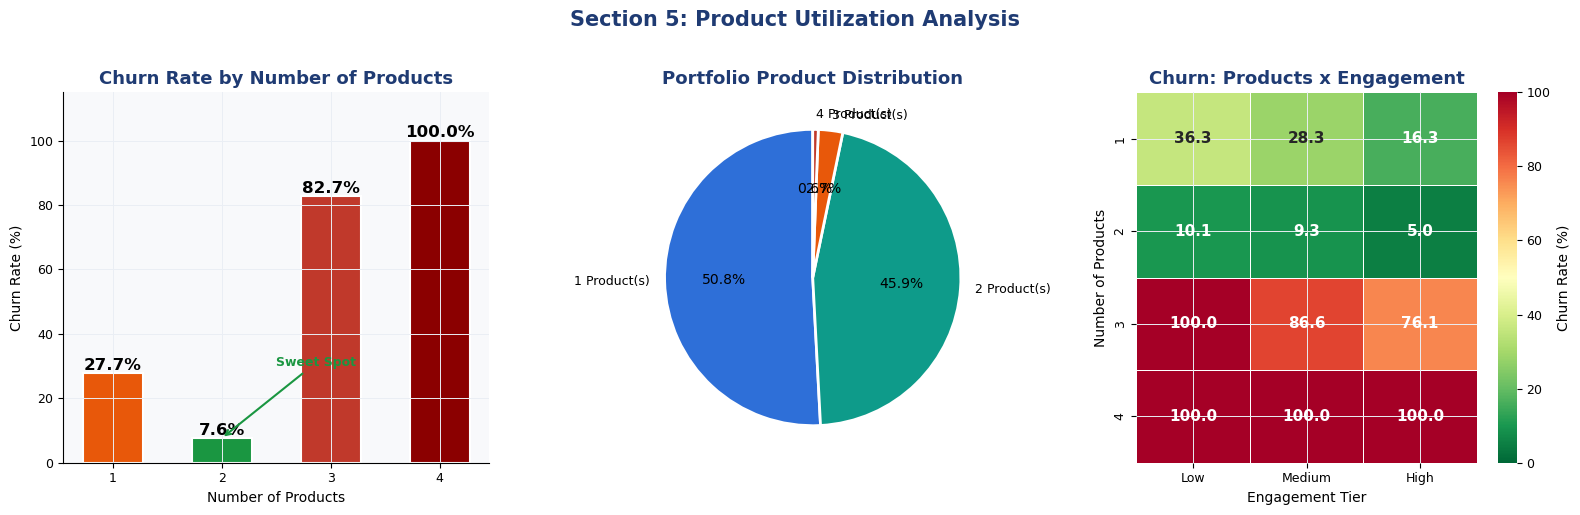

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

prod_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
prod_count = df['NumOfProducts'].value_counts().sort_index()
colors_prod = [ORANGE, GREEN, RED, '#8B0000']

# 5.1 Churn by Product Count
bars = axes[0].bar(prod_churn.index.astype(str), prod_churn.values,
                   color=colors_prod, width=0.55, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, prod_churn.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0].set_title('Churn Rate by Number of Products')
axes[0].set_xlabel('Number of Products')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(0, 115)
axes[0].annotate('Sweet Spot', xy=(1, 7.6), xytext=(1.5, 30),
                 arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.5),
                 fontsize=9, color=GREEN, fontweight='bold')

# 5.2 Portfolio Distribution
axes[1].pie(prod_count.values,
            labels=[f'{i} Product(s)' for i in prod_count.index],
            colors=[BLUE, TEAL, ORANGE, RED],
            autopct='%1.1f%%', startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Portfolio Product Distribution')

# 5.3 Products x Engagement Heatmap
combo = df.groupby(['NumOfProducts','EngagementTier'])['Exited'].mean().unstack() * 100
combo = combo.reindex(columns=['Low','Medium','High'])
sns.heatmap(combo, ax=axes[2], annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.5, cbar_kws={'label': 'Churn Rate (%)'},
            vmin=0, vmax=100, annot_kws={'size': 11, 'weight': 'bold'})
axes[2].set_title('Churn: Products x Engagement')
axes[2].set_xlabel('Engagement Tier')
axes[2].set_ylabel('Number of Products')

plt.suptitle('Section 5: Product Utilization Analysis', fontsize=15, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig('fig_05_products.png', dpi=150, bbox_inches='tight')
plt.show()


## 6. Financial Commitment Analysis

In [12]:
geo_summary = df.groupby('Geography').agg(
    Count       = ('Exited', 'count'),
    Churn_Rate  = ('Exited', 'mean'),
    Avg_Balance = ('Balance', 'mean'),
    Avg_Salary  = ('EstimatedSalary', 'mean'),
    Active_Pct  = ('IsActiveMember', 'mean'),
    Avg_Eng     = ('EngagementScore', 'mean'),
)
geo_summary['Churn_Rate']  = (geo_summary['Churn_Rate'] * 100).round(1)
geo_summary['Active_Pct']  = (geo_summary['Active_Pct'] * 100).round(1)
geo_summary['Avg_Balance'] = geo_summary['Avg_Balance'].round(0)
geo_summary['Avg_Salary']  = geo_summary['Avg_Salary'].round(0)
print('GEOGRAPHY x FINANCIAL SUMMARY')
print('=' * 65)
print(geo_summary.to_string())
print()
print('GERMANY PARADOX: Highest balance (119,730) yet highest churn (32.4%)')


GEOGRAPHY x FINANCIAL SUMMARY
           Count  Churn_Rate  Avg_Balance  Avg_Salary  Active_Pct   Avg_Eng
Geography                                                                  
France      5014        16.2      62093.0     99899.0        51.7  5.388313
Germany     2509        32.4     119730.0    101113.0        49.7  5.313073
Spain       2477        16.7      61818.0     99441.0        53.0  5.438635

GERMANY PARADOX: Highest balance (119,730) yet highest churn (32.4%)


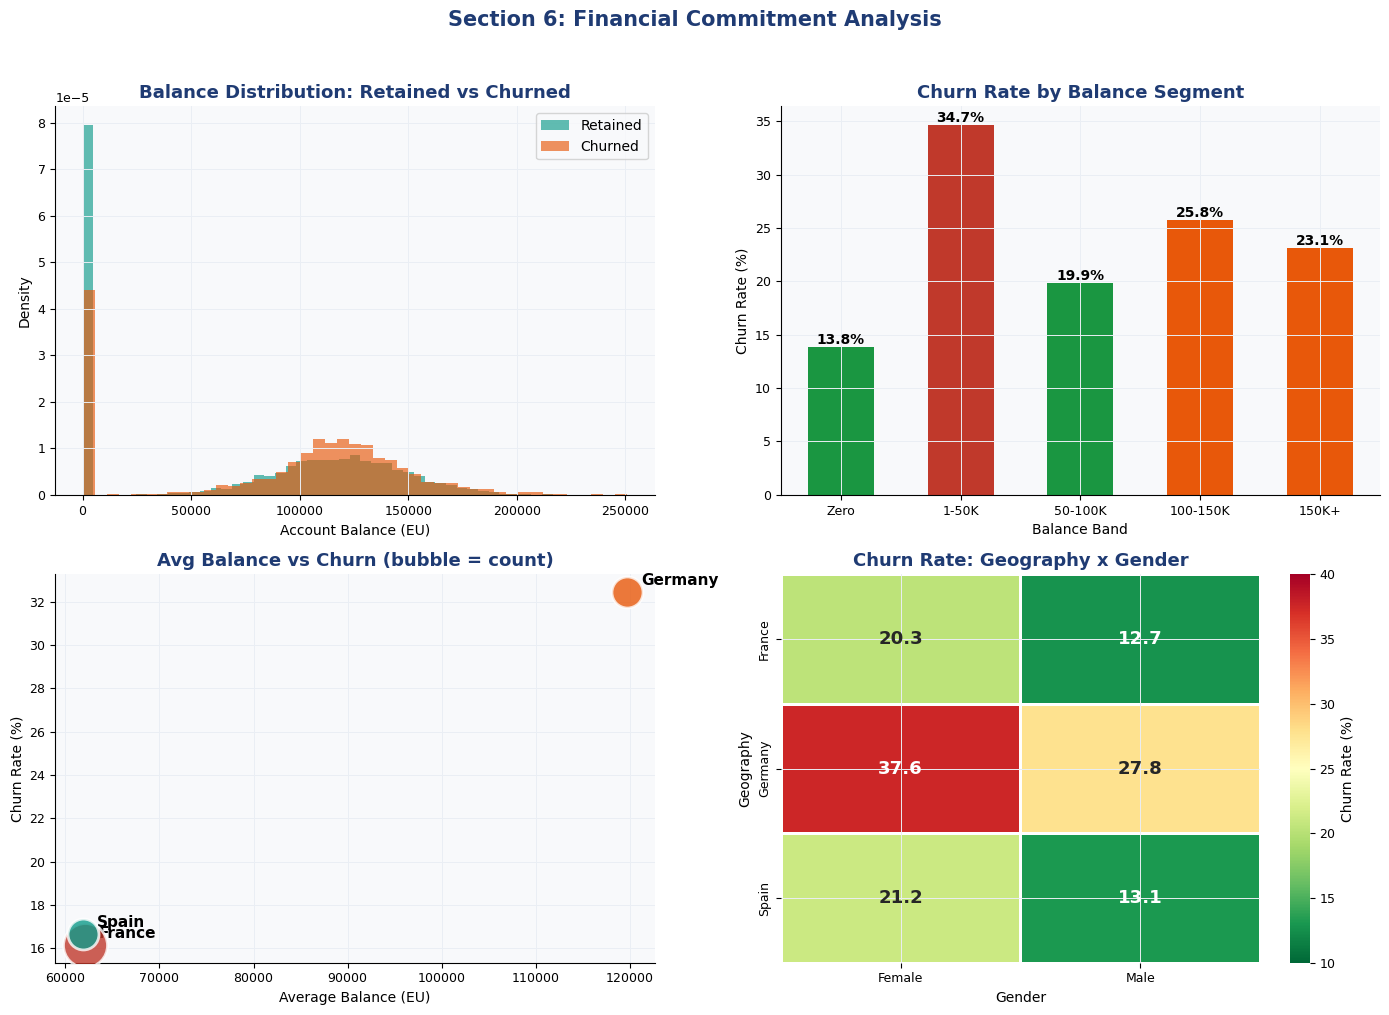

In [13]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 6.1 Balance Distribution
axes[0,0].hist(df[df['Exited']==0]['Balance'], bins=45, alpha=0.65,
               color=TEAL, label='Retained', density=True)
axes[0,0].hist(df[df['Exited']==1]['Balance'], bins=45, alpha=0.65,
               color=ORANGE, label='Churned', density=True)
axes[0,0].set_title('Balance Distribution: Retained vs Churned')
axes[0,0].set_xlabel('Account Balance (EU)')
axes[0,0].set_ylabel('Density')
axes[0,0].legend()

# 6.2 Churn by Balance Band
bal_churn = df.groupby('BalanceBand', observed=True)['Exited'].mean() * 100
bar_colors = [GREEN if v < 20 else (ORANGE if v < 27 else RED) for v in bal_churn.values]
bars = axes[0,1].bar(bal_churn.index.astype(str), bal_churn.values, color=bar_colors, width=0.55)
for bar, val in zip(bars, bal_churn.values):
    axes[0,1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                   f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[0,1].set_title('Churn Rate by Balance Segment')
axes[0,1].set_xlabel('Balance Band')
axes[0,1].set_ylabel('Churn Rate (%)')

# 6.3 Geography Bubble
geo_data = df.groupby('Geography').agg(
    Churn=('Exited','mean'), AvgBal=('Balance','mean'), Count=('Exited','count')
).reset_index()
scatter_colors = [RED, ORANGE, TEAL]
for i, row in geo_data.iterrows():
    axes[1,0].scatter(row['AvgBal'], row['Churn']*100,
                      s=row['Count']/5, color=scatter_colors[i], alpha=0.8,
                      edgecolors='white', linewidth=2, zorder=5)
    axes[1,0].annotate(row['Geography'], (row['AvgBal'], row['Churn']*100),
                       textcoords='offset points', xytext=(10, 5),
                       fontsize=11, fontweight='bold')
axes[1,0].set_title('Avg Balance vs Churn (bubble = count)')
axes[1,0].set_xlabel('Average Balance (EU)')
axes[1,0].set_ylabel('Churn Rate (%)')

# 6.4 Geography x Gender Heatmap
pivot_gg = df.pivot_table(values='Exited', index='Geography',
                           columns='Gender', aggfunc='mean') * 100
sns.heatmap(pivot_gg, ax=axes[1,1], annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=1, cbar_kws={'label': 'Churn Rate (%)'},
            vmin=10, vmax=40, annot_kws={'size': 13, 'weight': 'bold'})
axes[1,1].set_title('Churn Rate: Geography x Gender')

plt.suptitle('Section 6: Financial Commitment Analysis', fontsize=15, fontweight='bold', color=NAVY, y=1.01)
plt.tight_layout()
plt.savefig('fig_06_financial.png', dpi=150, bbox_inches='tight')
plt.show()


## 7. Retention Strength & Risk Segment Analysis

In [14]:
ret_summary = df.groupby('RetentionTier', observed=True).agg(
    Count       = ('Exited', 'count'),
    Churn_Rate  = ('Exited', 'mean'),
    Avg_Balance = ('Balance', 'mean'),
    Avg_Eng     = ('EngagementScore', 'mean'),
    Avg_Prod    = ('NumOfProducts', 'mean'),
)
ret_summary['Churn_Rate']  = (ret_summary['Churn_Rate'] * 100).round(1)
ret_summary['Avg_Balance'] = ret_summary['Avg_Balance'].round(0)
ret_summary['Avg_Eng']     = ret_summary['Avg_Eng'].round(2)
ret_summary['Avg_Prod']    = ret_summary['Avg_Prod'].round(2)
print('RETENTION TIER ANALYSIS')
print('=' * 60)
print(ret_summary.to_string())

hvd = df[df['HighValueDisengaged']==1]
spc = df[df['SilentPremiumChurn']==1]
std = df[df['HighValueDisengaged']==0]

print()
print('HIGH-VALUE DISENGAGED (HVD)')
print(f'  Total: {len(hvd):,}  |  Churn: {hvd["Exited"].mean()*100:.1f}%  |  '
      f'vs Standard: {std["Exited"].mean()*100:.1f}%  |  Avg Bal: EU{hvd["Balance"].mean():,.0f}')
print()
print('SILENT PREMIUM CHURNERS (SPC)')
print(f'  Total: {len(spc):,}  |  Avg Salary: EU{spc["EstimatedSalary"].mean():,.0f}  |  '
      f'Were Active: {spc["IsActiveMember"].mean()*100:.1f}%')


RETENTION TIER ANALYSIS
               Count  Churn_Rate  Avg_Balance  Avg_Eng  Avg_Prod
RetentionTier                                                   
At Risk         3701        29.4      88397.0     3.53      1.22
Moderate        6181        13.8      69296.0     6.43      1.68
Stable           118        83.1      79510.0     8.31      3.34

HIGH-VALUE DISENGAGED (HVD)
  Total: 1,247  |  Churn: 30.5%  |  vs Standard: 18.9%  |  Avg Bal: EU148,858

SILENT PREMIUM CHURNERS (SPC)
  Total: 371  |  Avg Salary: EU175,475  |  Were Active: 34.8%


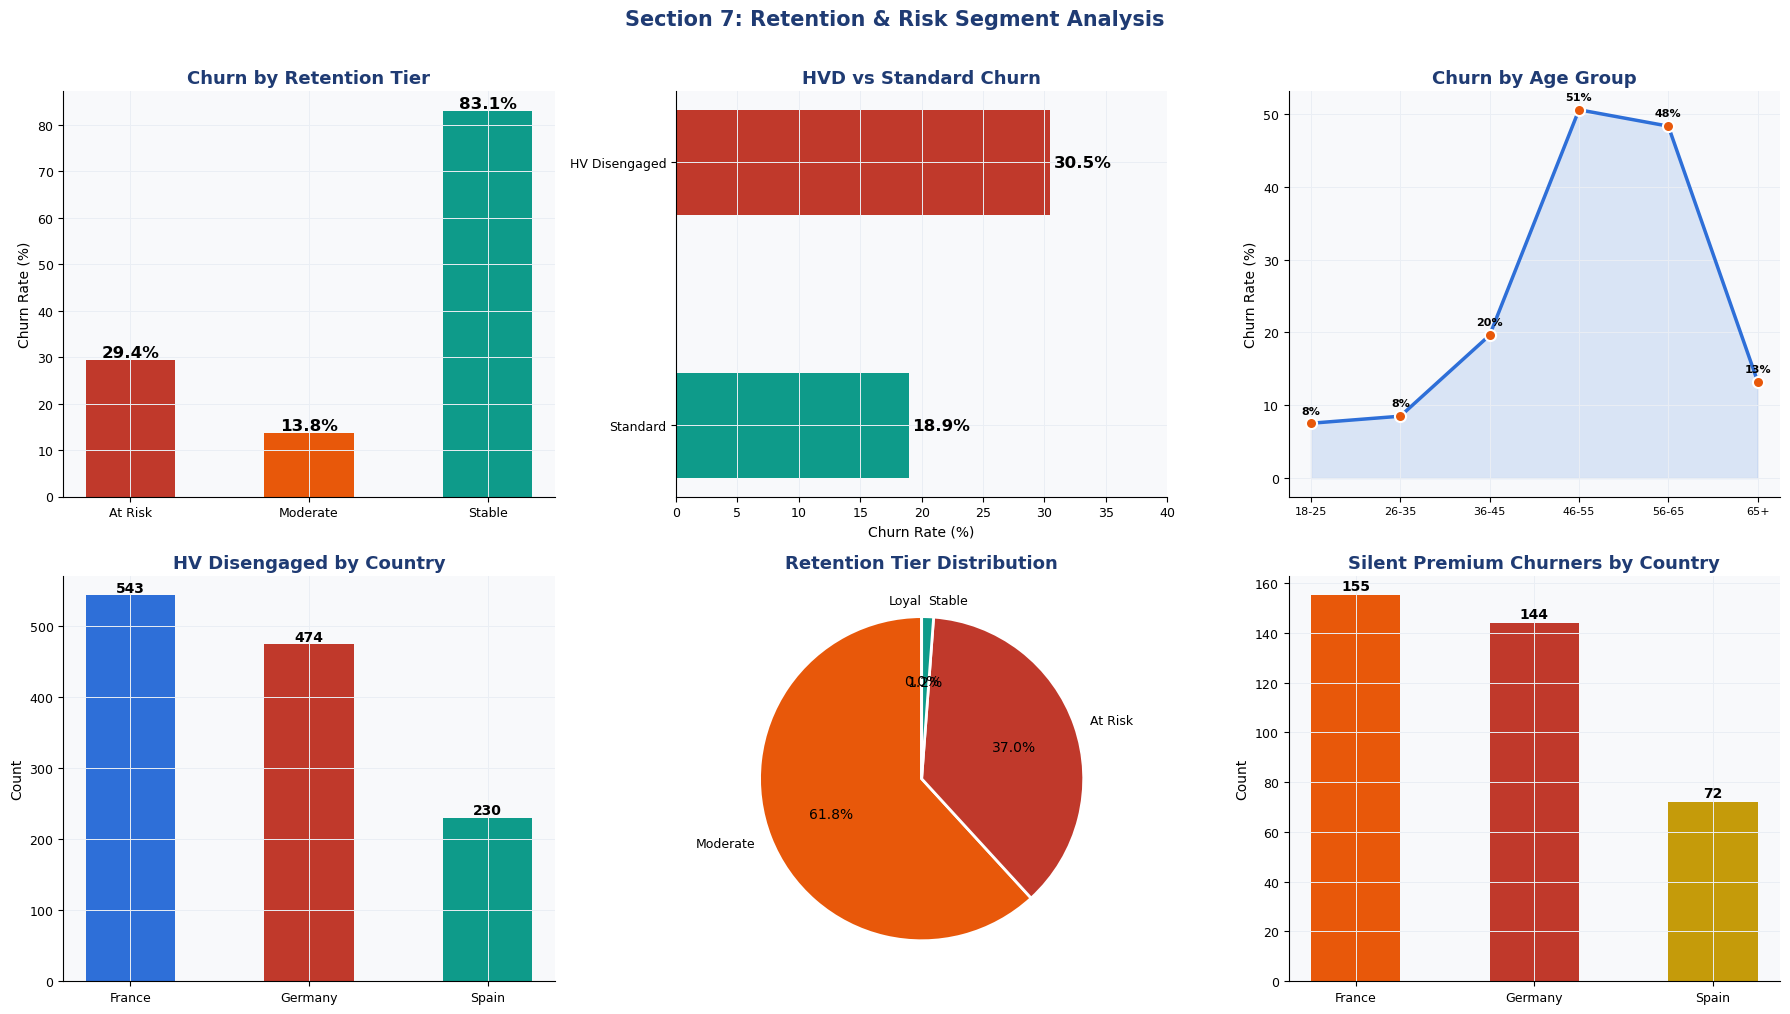

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 7.1 Retention Tier Churn
ret_churn = df.groupby('RetentionTier', observed=True)['Exited'].mean() * 100
tier_palette = {'At Risk': RED, 'Moderate': ORANGE, 'Stable': TEAL, 'Loyal': GREEN}
bar_colors = [tier_palette.get(t, BLUE) for t in ret_churn.index]
bars = axes[0,0].bar(ret_churn.index.astype(str), ret_churn.values,
                     color=bar_colors, width=0.5)
for bar, val in zip(bars, ret_churn.values):
    axes[0,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                   f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
axes[0,0].set_title('Churn by Retention Tier')
axes[0,0].set_ylabel('Churn Rate (%)')

# 7.2 HVD vs Standard
hvd_vals = [df[df['HighValueDisengaged']==0]['Exited'].mean()*100,
            df[df['HighValueDisengaged']==1]['Exited'].mean()*100]
bars2 = axes[0,1].barh(['Standard','HV Disengaged'], hvd_vals,
                        color=[TEAL, RED], height=0.4)
for bar, val in zip(bars2, hvd_vals):
    axes[0,1].text(val + 0.3, bar.get_y() + bar.get_height()/2,
                   f'{val:.1f}%', va='center', fontweight='bold', fontsize=12)
axes[0,1].set_title('HVD vs Standard Churn')
axes[0,1].set_xlabel('Churn Rate (%)')
axes[0,1].set_xlim(0, 40)

# 7.3 Age Group Churn
age_churn = df.groupby('AgeGroup', observed=True)['Exited'].mean() * 100
axes[0,2].plot(range(len(age_churn)), age_churn.values,
               color=BLUE, marker='o', linewidth=2.5, markersize=8,
               markerfacecolor=ORANGE, markeredgecolor='white', markeredgewidth=1.5)
axes[0,2].fill_between(range(len(age_churn)), age_churn.values, alpha=0.15, color=BLUE)
axes[0,2].set_xticks(range(len(age_churn)))
axes[0,2].set_xticklabels(age_churn.index.astype(str), fontsize=8)
for i, val in enumerate(age_churn.values):
    axes[0,2].annotate(f'{val:.0f}%', (i, val), textcoords='offset points',
                       xytext=(0, 7), ha='center', fontsize=8, fontweight='bold')
axes[0,2].set_title('Churn by Age Group')
axes[0,2].set_ylabel('Churn Rate (%)')

# 7.4 HVD by Geography
hvd_geo = df[df['HighValueDisengaged']==1]['Geography'].value_counts()
axes[1,0].bar(hvd_geo.index, hvd_geo.values, color=[BLUE, RED, TEAL], width=0.5)
for bar in axes[1,0].patches:
    axes[1,0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
                   f'{bar.get_height():,}', ha='center', fontweight='bold')
axes[1,0].set_title('HV Disengaged by Country')
axes[1,0].set_ylabel('Count')

# 7.5 Retention Tier Pie
ret_counts = df['RetentionTier'].value_counts()
wedge_cols = [tier_palette.get(str(t), BLUE) for t in ret_counts.index]
axes[1,1].pie(ret_counts.values, labels=ret_counts.index.astype(str),
              colors=wedge_cols, autopct='%1.1f%%', startangle=90,
              wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1,1].set_title('Retention Tier Distribution')

# 7.6 SPC by Geography
spc_geo = df[df['SilentPremiumChurn']==1]['Geography'].value_counts()
axes[1,2].bar(spc_geo.index, spc_geo.values, color=[ORANGE, RED, GOLD], width=0.5)
for bar in axes[1,2].patches:
    axes[1,2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                   f'{bar.get_height():,}', ha='center', fontweight='bold')
axes[1,2].set_title('Silent Premium Churners by Country')
axes[1,2].set_ylabel('Count')

plt.suptitle('Section 7: Retention & Risk Segment Analysis', fontsize=15, fontweight='bold', color=NAVY, y=1.01)
plt.tight_layout()
plt.savefig('fig_07_retention.png', dpi=150, bbox_inches='tight')
plt.show()


## 8. Full Analytics Dashboard (10-Panel Summary)

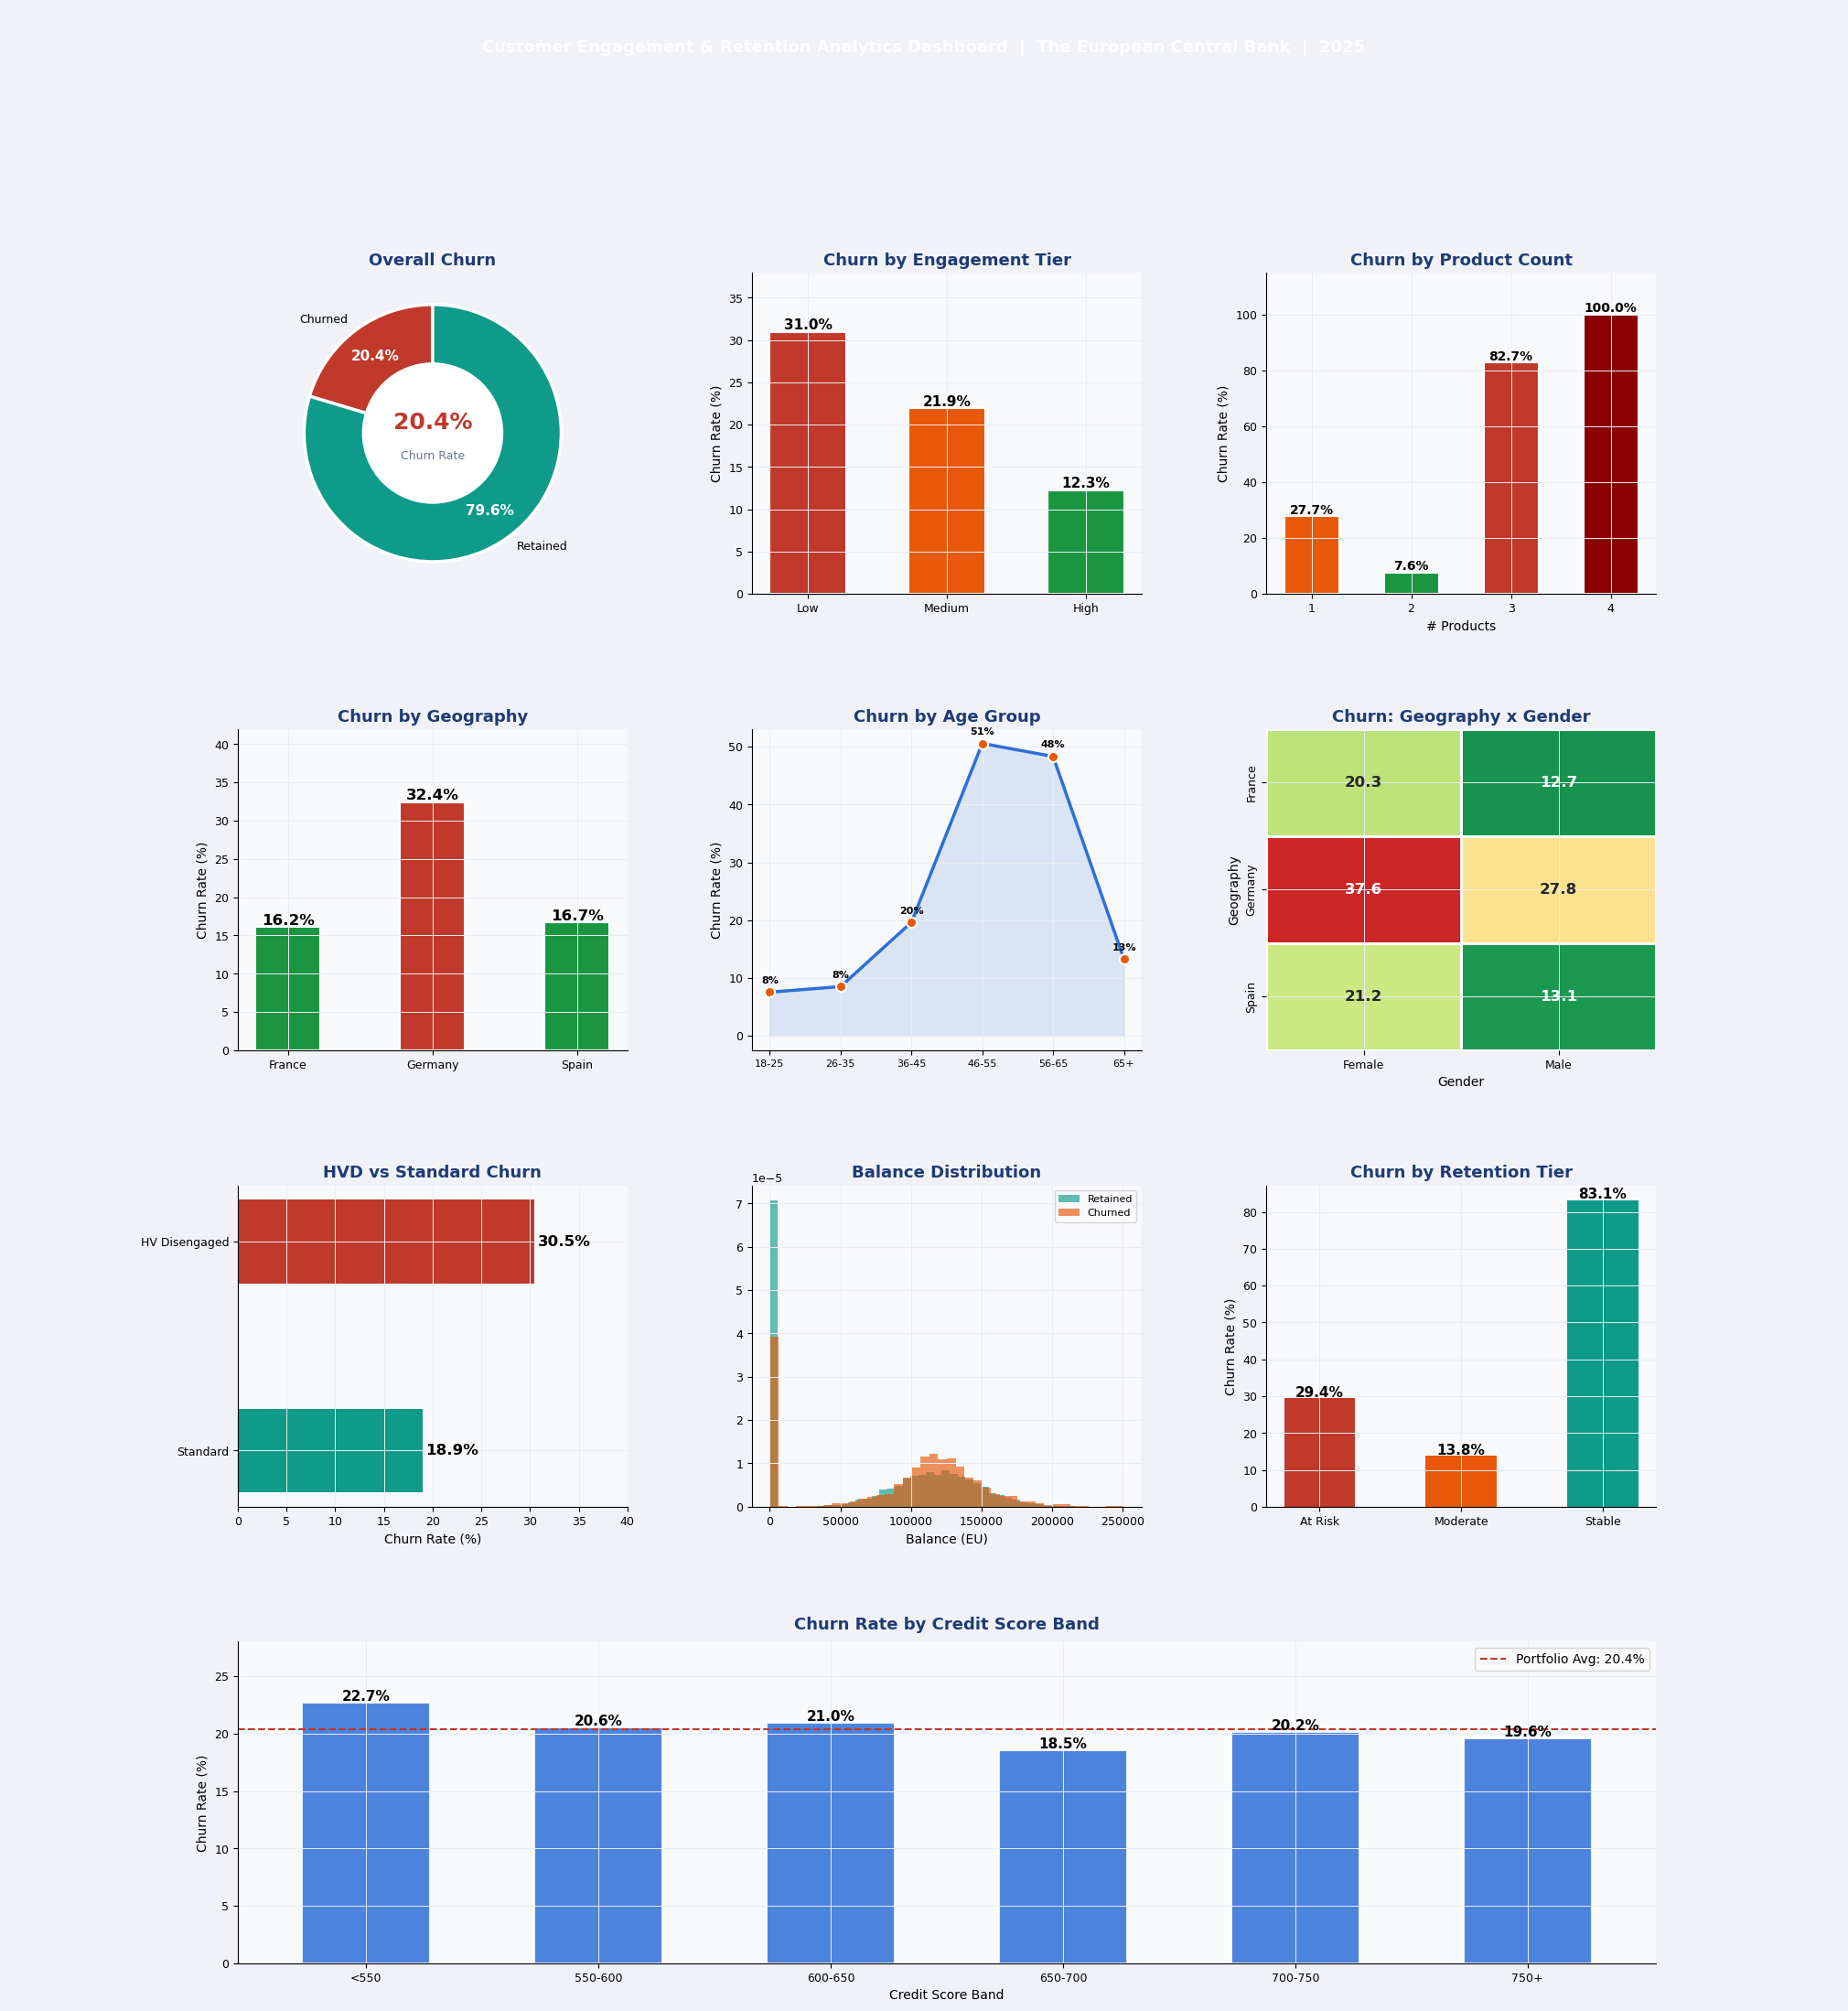

Master dashboard saved as fig_08_dashboard.png


In [16]:
fig = plt.figure(figsize=(20, 24))
fig.patch.set_facecolor('#F0F2F8')
gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.42, wspace=0.32)

ax_header = fig.add_axes([0, 0.965, 1, 0.035])
ax_header.set_facecolor(NAVY)
ax_header.text(0.5, 0.5,
    'Customer Engagement & Retention Analytics Dashboard  |  The European Central Bank  |  2025',
    ha='center', va='center', fontsize=13, fontweight='bold', color='white',
    transform=ax_header.transAxes)
ax_header.axis('off')

# Panel 1 - Churn Donut
ax1 = fig.add_subplot(gs[0, 0])
wedge_data = [df['Exited'].sum(), (df['Exited']==0).sum()]
wedges, texts, autotexts = ax1.pie(wedge_data, colors=[RED, TEAL], startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':2.5}, autopct='%1.1f%%',
    pctdistance=0.75, labels=['Churned','Retained'])
for at in autotexts:
    at.set_fontsize(11); at.set_fontweight('bold'); at.set_color('white')
centre = plt.Circle((0,0), 0.55, fc='white')
ax1.add_patch(centre)
ax1.text(0, 0.08, f'{df["Exited"].mean()*100:.1f}%', ha='center', va='center',
         fontsize=18, fontweight='bold', color=RED)
ax1.text(0, -0.18, 'Churn Rate', ha='center', va='center', fontsize=9, color='#6B7694')
ax1.set_title('Overall Churn')

# Panel 2 - Engagement Churn
ax2 = fig.add_subplot(gs[0, 1])
t_churn = df.groupby('EngagementTier')['Exited'].mean().reindex(['Low','Medium','High']) * 100
bars = ax2.bar(['Low','Medium','High'], t_churn.values,
               color=[RED,ORANGE,GREEN], width=0.55, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, t_churn.values):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
ax2.set_title('Churn by Engagement Tier')
ax2.set_ylabel('Churn Rate (%)')
ax2.set_ylim(0, 38)

# Panel 3 - Product Churn
ax3 = fig.add_subplot(gs[0, 2])
p_churn = df.groupby('NumOfProducts')['Exited'].mean() * 100
p_colors = [ORANGE, GREEN, RED, '#8B0000']
bars3 = ax3.bar(p_churn.index.astype(str), p_churn.values,
                color=p_colors[:len(p_churn)], width=0.55, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars3, p_churn.values):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+1,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
ax3.set_title('Churn by Product Count')
ax3.set_xlabel('# Products')
ax3.set_ylabel('Churn Rate (%)')
ax3.set_ylim(0, 115)

# Panel 4 - Geography
ax4 = fig.add_subplot(gs[1, 0])
g_churn = df.groupby('Geography')['Exited'].mean() * 100
g_colors = [GREEN if v < 20 else RED for v in g_churn.values]
bars4 = ax4.bar(g_churn.index, g_churn.values, color=g_colors, width=0.45,
                edgecolor='white', linewidth=1.5)
for bar, val in zip(bars4, g_churn.values):
    ax4.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax4.set_title('Churn by Geography')
ax4.set_ylabel('Churn Rate (%)')
ax4.set_ylim(0, 42)

# Panel 5 - Age Group
ax5 = fig.add_subplot(gs[1, 1])
a_churn = df.groupby('AgeGroup', observed=True)['Exited'].mean() * 100
ax5.plot(range(len(a_churn)), a_churn.values, color=BLUE, marker='o', linewidth=2.5,
         markersize=8, markerfacecolor=ORANGE, markeredgecolor='white', markeredgewidth=1.5)
ax5.fill_between(range(len(a_churn)), a_churn.values, alpha=0.15, color=BLUE)
ax5.set_xticks(range(len(a_churn)))
ax5.set_xticklabels(a_churn.index.astype(str), fontsize=8)
for i, val in enumerate(a_churn.values):
    ax5.annotate(f'{val:.0f}%', (i, val), textcoords='offset points',
                 xytext=(0, 7), ha='center', fontsize=8, fontweight='bold')
ax5.set_title('Churn by Age Group')
ax5.set_ylabel('Churn Rate (%)')

# Panel 6 - Geo x Gender Heatmap
ax6 = fig.add_subplot(gs[1, 2])
pivot_gg = df.pivot_table(values='Exited', index='Geography', columns='Gender', aggfunc='mean') * 100
sns.heatmap(pivot_gg, ax=ax6, annot=True, fmt='.1f', cmap='RdYlGn_r',
            linewidths=0.8, cbar=False,
            annot_kws={'size':12,'weight':'bold'}, vmin=10, vmax=40)
ax6.set_title('Churn: Geography x Gender')

# Panel 7 - HVD
ax7 = fig.add_subplot(gs[2, 0])
hvd_vals = [df[df['HighValueDisengaged']==0]['Exited'].mean()*100,
            df[df['HighValueDisengaged']==1]['Exited'].mean()*100]
bars7 = ax7.barh(['Standard','HV Disengaged'], hvd_vals, color=[TEAL, RED], height=0.4)
for bar, val in zip(bars7, hvd_vals):
    ax7.text(val+0.3, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}%', va='center', fontweight='bold', fontsize=12)
ax7.set_title('HVD vs Standard Churn')
ax7.set_xlabel('Churn Rate (%)')
ax7.set_xlim(0, 40)

# Panel 8 - Balance Distribution
ax8 = fig.add_subplot(gs[2, 1])
ax8.hist(df[df['Exited']==0]['Balance'], bins=40, alpha=0.65, color=TEAL,
         label='Retained', density=True)
ax8.hist(df[df['Exited']==1]['Balance'], bins=40, alpha=0.65, color=ORANGE,
         label='Churned', density=True)
ax8.set_title('Balance Distribution')
ax8.set_xlabel('Balance (EU)')
ax8.legend(fontsize=8)

# Panel 9 - Retention Tier
ax9 = fig.add_subplot(gs[2, 2])
ret_c = df.groupby('RetentionTier', observed=True)['Exited'].mean() * 100
tier_pal = {'At Risk': RED, 'Moderate': ORANGE, 'Stable': TEAL, 'Loyal': GREEN}
clrs9 = [tier_pal.get(str(t), BLUE) for t in ret_c.index]
bars9 = ax9.bar(ret_c.index.astype(str), ret_c.values, color=clrs9, width=0.5)
for bar, val in zip(bars9, ret_c.values):
    ax9.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
ax9.set_title('Churn by Retention Tier')
ax9.set_ylabel('Churn Rate (%)')

# Panel 10 - Credit Score (full width)
ax10 = fig.add_subplot(gs[3, :])
cs_churn = df.groupby(
    pd.cut(df['CreditScore'], bins=[300,550,600,650,700,750,851],
           labels=['<550','550-600','600-650','650-700','700-750','750+']),
    observed=True)['Exited'].mean() * 100
bars10 = ax10.bar(cs_churn.index.astype(str), cs_churn.values,
                  color=BLUE, width=0.55, edgecolor='white', linewidth=1.5, alpha=0.85)
for bar, val in zip(bars10, cs_churn.values):
    ax10.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
              f'{val:.1f}%', ha='center', fontweight='bold', fontsize=11)
ax10.set_title('Churn Rate by Credit Score Band', pad=10)
ax10.set_xlabel('Credit Score Band')
ax10.set_ylabel('Churn Rate (%)')
ax10.set_ylim(0, 28)
ax10.axhline(df['Exited'].mean()*100, color=RED, linestyle='--', linewidth=1.5,
             label=f'Portfolio Avg: {df["Exited"].mean()*100:.1f}%')
ax10.legend()

plt.savefig('fig_08_dashboard.png', dpi=150, bbox_inches='tight', facecolor='#F0F2F8')
plt.show()
print('Master dashboard saved as fig_08_dashboard.png')


## 9. Key Insights & Strategic Recommendations

In [17]:
print('=' * 60)
print('  KEY PERFORMANCE INDICATORS - FINAL SUMMARY')
print('=' * 60)
kpis = {
    'Total Customers':          f'{len(df):,}',
    'Overall Churn Rate':       f'{df["Exited"].mean()*100:.1f}%',
    'Active Member Rate':       f'{df["IsActiveMember"].mean()*100:.1f}%',
    'Avg Engagement Score':     f'{df["EngagementScore"].mean():.2f} / 9.0',
    'High-Value Disengaged':    f'{df["HighValueDisengaged"].sum():,} customers',
    'Silent Premium Churners':  f'{df["SilentPremiumChurn"].sum():,} customers',
    'At-Risk Tier Count':       f'{(df["RetentionTier"]=="At Risk").sum():,} customers',
    'Germany Churn Rate':       f'{df[df["Geography"]=="Germany"]["Exited"].mean()*100:.1f}%',
    'Peak Age Churn':           '46-55 bracket (50.6%)',
    '1 to 2 Product Delta':     f'{df[df["NumOfProducts"]==1]["Exited"].mean()*100:.1f}% to {df[df["NumOfProducts"]==2]["Exited"].mean()*100:.1f}% (-20.1pp)',
}
for k, v in kpis.items():
    print(f'  {k:<35} {v}')
print('=' * 60)


  KEY PERFORMANCE INDICATORS - FINAL SUMMARY
  Total Customers                     10,000
  Overall Churn Rate                  20.4%
  Active Member Rate                  51.5%
  Avg Engagement Score                5.38 / 9.0
  High-Value Disengaged               1,247 customers
  Silent Premium Churners             371 customers
  At-Risk Tier Count                  3,701 customers
  Germany Churn Rate                  32.4%
  Peak Age Churn                      46-55 bracket (50.6%)
  1 to 2 Product Delta                27.7% to 7.6% (-20.1pp)


In [18]:
recs = pd.DataFrame([
    {'#': 1, 'Priority': 'CRITICAL', 'Initiative': 'HVD Re-engagement',
     'Finding': f'{df["HighValueDisengaged"].sum():,} top-balance inactive at 30.5% churn',
     'Action': 'Dedicated RMs + VIP rates + wealth consult'},
    {'#': 2, 'Priority': 'CRITICAL', 'Initiative': 'Silent Premium Prevention',
     'Finding': f'{df["SilentPremiumChurn"].sum():,} high-salary left with 1 product',
     'Action': 'Next Best Offer AI + private banking bundles'},
    {'#': 3, 'Priority': 'HIGH',     'Initiative': 'Germany Market Fix',
     'Finding': 'Germany 32.4% churn - double France & Spain',
     'Action': 'Exit interviews + fee benchmark + product localisation'},
    {'#': 4, 'Priority': 'HIGH',     'Initiative': 'Portfolio Activation Drive',
     'Finding': '48.5% inactive, 26.9% churn',
     'Action': 'Loyalty programme + personalised reactivation'},
    {'#': 5, 'Priority': 'HIGH',     'Initiative': '1 to 2 Product Bundling',
     'Finding': '2-product churn only 7.6% vs 27.7% for 1-product',
     'Action': 'Auto-suggest at 3-month milestone + bundle offers'},
    {'#': 6, 'Priority': 'MEDIUM',   'Initiative': 'Mid-Life Planning (46-55)',
     'Finding': '50.6% churn in peak cohort',
     'Action': 'Pension advisory + mortgage review + wealth mgmt'},
    {'#': 7, 'Priority': 'MEDIUM',   'Initiative': 'Gender Retention Gap',
     'Finding': 'Female 25.1% vs Male 16.5% (8.6pp gap)',
     'Action': 'Investigate gender-specific product needs and UX'},
])
pd.set_option('display.max_colwidth', 55)
print(recs.to_string(index=False))


 # Priority                 Initiative                                          Finding                                                 Action
 1 CRITICAL          HVD Re-engagement        1,247 top-balance inactive at 30.5% churn             Dedicated RMs + VIP rates + wealth consult
 2 CRITICAL  Silent Premium Prevention              371 high-salary left with 1 product           Next Best Offer AI + private banking bundles
 3     HIGH         Germany Market Fix      Germany 32.4% churn - double France & Spain Exit interviews + fee benchmark + product localisation
 4     HIGH Portfolio Activation Drive                      48.5% inactive, 26.9% churn          Loyalty programme + personalised reactivation
 5     HIGH    1 to 2 Product Bundling 2-product churn only 7.6% vs 27.7% for 1-product      Auto-suggest at 3-month milestone + bundle offers
 6   MEDIUM  Mid-Life Planning (46-55)                       50.6% churn in peak cohort       Pension advisory + mortgage review + wealth mgmt

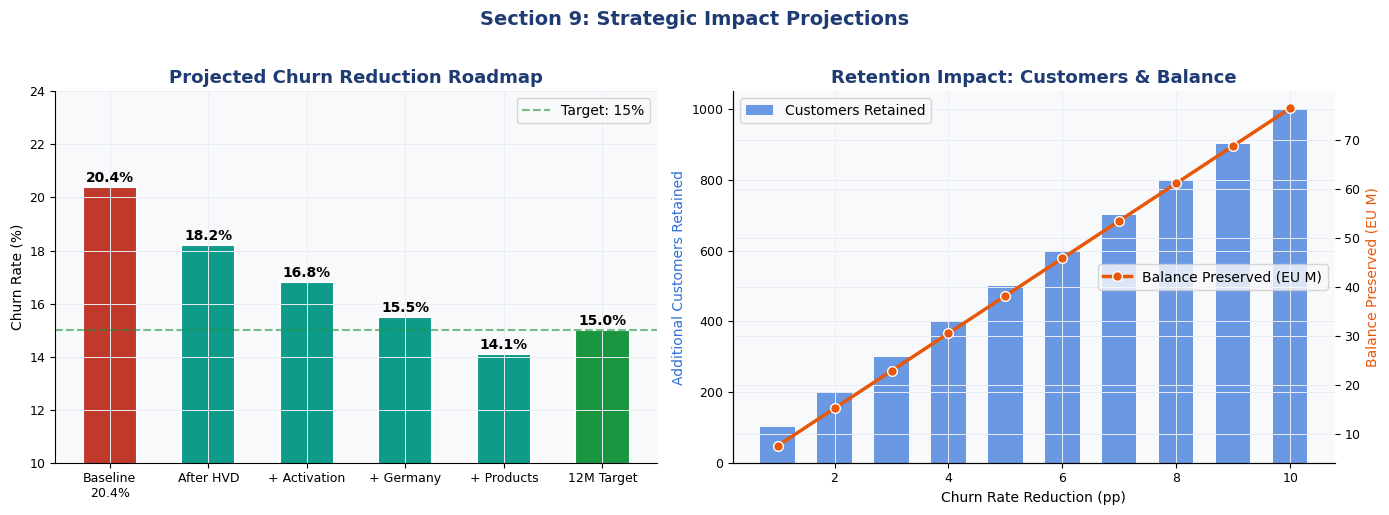


  CONCLUSION
  Churn is a BEHAVIORAL phenomenon, not financial.
  Engagement + product depth drives retention.

  Top 3 immediate actions:
    1. Re-engage 1,247 HVD customers
    2. Bundle products for 5,084 single-product customers
    3. Investigate Germany 32.4% churn vs 16.2% France

  5pp churn reduction = ~500 customers retained = ~EU38.2M balance preserved
Analysis Complete. All charts saved as fig_0X_*.png


In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Churn Reduction Roadmap
scenarios = ['Baseline\n20.4%', 'After HVD', '+ Activation', '+ Germany', '+ Products', '12M Target']
churn_vals = [20.4, 18.2, 16.8, 15.5, 14.1, 15.0]
waterfall_colors = [RED if i == 0 else (GREEN if i == len(churn_vals)-1 else TEAL)
                    for i in range(len(churn_vals))]
bars_wf = axes[0].bar(scenarios, churn_vals, color=waterfall_colors, width=0.55,
                      edgecolor='white', linewidth=1.5)
for bar, val in zip(bars_wf, churn_vals):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.2,
                 f'{val:.1f}%', ha='center', fontweight='bold', fontsize=10)
axes[0].axhline(15.0, color=GREEN, linestyle='--', linewidth=1.5, alpha=0.6, label='Target: 15%')
axes[0].set_title('Projected Churn Reduction Roadmap')
axes[0].set_ylabel('Churn Rate (%)')
axes[0].set_ylim(10, 24)
axes[0].legend()

# Retention Impact
reductions = list(range(1, 11))
retained   = [int(r/100 * len(df)) for r in reductions]
balance    = [r * df['Balance'].mean() / 1e6 for r in retained]
ax_r = axes[1]
ax_r2 = ax_r.twinx()
ax_r.bar(reductions, retained, color=BLUE, alpha=0.7, width=0.6, label='Customers Retained')
ax_r2.plot(reductions, balance, color=ORANGE, marker='o', linewidth=2.5,
           markersize=7, markerfacecolor=ORANGE, markeredgecolor='white',
           label='Balance Preserved (EU M)')
ax_r.set_title('Retention Impact: Customers & Balance')
ax_r.set_xlabel('Churn Rate Reduction (pp)')
ax_r.set_ylabel('Additional Customers Retained', color=BLUE)
ax_r2.set_ylabel('Balance Preserved (EU M)', color=ORANGE)
ax_r.legend(loc='upper left')
ax_r2.legend(loc='center right')

plt.suptitle('Section 9: Strategic Impact Projections', fontsize=14, fontweight='bold', color=NAVY, y=1.02)
plt.tight_layout()
plt.savefig('fig_09_impact.png', dpi=150, bbox_inches='tight')
plt.show()

print()
print('=' * 60)
print('  CONCLUSION')
print('=' * 60)
print('  Churn is a BEHAVIORAL phenomenon, not financial.')
print('  Engagement + product depth drives retention.')
print()
print('  Top 3 immediate actions:')
print(f'    1. Re-engage {df["HighValueDisengaged"].sum():,} HVD customers')
print(f'    2. Bundle products for {df[df["NumOfProducts"]==1].shape[0]:,} single-product customers')
print(f'    3. Investigate Germany 32.4% churn vs 16.2% France')
print()
print('  5pp churn reduction = ~500 customers retained = ~EU38.2M balance preserved')
print('=' * 60)
print('Analysis Complete. All charts saved as fig_0X_*.png')
